# Proyek Analisis Data: [Bike Sharing Dataset]
- **Nama:** [Muhammad Almustofa Khanafi]
- **Email:** [23040700074@student.umj.ac.id]
- **ID Dicoding:** [muhammad_almustofa_khanafi_EUa8]

## Menentukan Pertanyaan Bisnis

- Selama 3 bulan terakhir, pada hari apa total penyewaan paling tinggi untuk acuan jadwal promosi?
- Berdasarkan data bulan lalu, pada rentang jam berapa penyewaan mencapai puncaknya?

## Import Semua Packages/Library yang Digunakan

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

Memuat tabel Day


In [ ]:
day_df = pd.read_csv('day.csv')
day_df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600


Memuat tabel Hour

In [ ]:
hour_df = pd.read_csv('hour.csv')
hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dari kode day_df menampilkan 5 baris dataframe yang isinya seperti pada tabel diatas.
- Dari kode hour_df menampilkan 5 baris dataframe yang isinya seperti pada tabel diatas.

### Assessing Data

Menilai Data day_df

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB


In [ ]:
print("Jumlah Duplikasi : ", day_df.duplicated().sum())
day_df.describe()

Jumlah Duplikasi :  0


,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
std,211.165812,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000


Menilai Data hour_df

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


Dapat perhatikan, jumlah data pada hour_df telah lengkap atau dengan kata lain tidak ada missing value di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object (ini digunakan untuk tipe data string).

Berikutnya, kita perlu memeriksa duplikasi dan ringkasan parameter statistik dari kolom numerik pada hour_df. Proses ini dilakukan dengan menjalankan kode berikut:

In [ ]:
print("Jumlah Duplikasi : ", hour_df.duplicated().sum())
hour_df.describe()

Jumlah Duplikasi :  0


,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


**Insight:**
- Dapat perhatikan, jumlah data pada day_df telah lengkap atau dengan kata lain tidak ada missing value di dalamnya. Akan tetapi, terdapat kesalahan tipe data untuk kolom dteday. Kolom tersebut harusnya direpresentasikan sebagai tipe data datetime, bukan object (ini digunakan untuk tipe data string).

- Dan untuk hour_df memiliki masalah yang sama, yaitu terdapat kesalahan tipe data untuk kolom dteday. Yang harusnya kolom tersebut berisi tipe data datetime, bukan object.

### Cleaning Data

Membersihkan Data day_df

In [ ]:
datetime_columns = ["dteday"]

for column in datetime_columns:
    day_df[column] = pd.to_datetime(day_df[column])

In [ ]:
day_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     731 non-null    int64         
 1   dteday      731 non-null    datetime64[ns]
 2   season      731 non-null    int64         
 3   yr          731 non-null    int64         
 4   mnth        731 non-null    int64         
 5   holiday     731 non-null    int64         
 6   weekday     731 non-null    int64         
 7   workingday  731 non-null    int64         
 8   weathersit  731 non-null    int64         
 9   temp        731 non-null    float64       
 10  atemp       731 non-null    float64       
 11  hum         731 non-null    float64       
 12  windspeed   731 non-null    float64       
 13  casual      731 non-null    int64         
 14  registered  731 non-null    int64         
 15  cnt         731 non-null    int64         
dtypes: datetime64[ns](1), floa

Membersihkan Data hour_day

In [ ]:
hour_df = pd.read_csv('hour.csv')
datetime_columns = ["dteday"]

for column in datetime_columns:
    hour_df[column] = pd.to_datetime(hour_df[column])

In [ ]:
hour_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   instant     17379 non-null  int64         
 1   dteday      17379 non-null  datetime64[ns]
 2   season      17379 non-null  int64         
 3   yr          17379 non-null  int64         
 4   mnth        17379 non-null  int64         
 5   hr          17379 non-null  int64         
 6   holiday     17379 non-null  int64         
 7   weekday     17379 non-null  int64         
 8   workingday  17379 non-null  int64         
 9   weathersit  17379 non-null  int64         
 10  temp        17379 non-null  float64       
 11  atemp       17379 non-null  float64       
 12  hum         17379 non-null  float64       
 13  windspeed   17379 non-null  float64       
 14  casual      17379 non-null  int64         
 15  registered  17379 non-null  int64         
 16  cnt         17379 non-

**Insight:**
- Untuk mengatasinya masalah pada tipe data day_df, disini saya mengganti tipe datanya yang dari object ke datetime dengan menggunakan function to_datetime().
- Untuk mengatasinya masalah pada tipe data hour_df, disini saya mengganti tipe datanya yang dari object ke datetime dengan menggunakan function to_datetime().

## Exploratory Data Analysis (EDA)

### Explore Data day_df

In [ ]:
day_df.describe(include="all")

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,731.000000,731,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000,731.000000
mean,366.000000,2012-01-01 00:00:00,2.496580,0.500684,6.519836,0.028728,2.997264,0.683995,1.395349,0.495385,0.474354,0.627894,0.190486,848.176471,3656.172367,4504.348837
min,1.000000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.059130,0.079070,0.000000,0.022392,2.000000,20.000000,22.000000
25%,183.500000,2011-07-02 12:00:00,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,0.337083,0.337842,0.520000,0.134950,315.500000,2497.000000,3152.000000
50%,366.000000,2012-01-01 00:00:00,3.000000,1.000000,7.000000,0.000000,3.000000,1.000000,1.000000,0.498333,0.486733,0.626667,0.180975,713.000000,3662.000000,4548.000000
75%,548.500000,2012-07-01 12:00:00,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,0.655417,0.608602,0.730209,0.233214,1096.000000,4776.500000,5956.000000
max,731.000000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,0.861667,0.840896,0.972500,0.507463,3410.000000,6946.000000,8714.000000
std,211.165812,NaN,1.110807,0.500342,3.451913,0.167155,2.004787,0.465233,0.544894,0.183051,0.162961,0.142429,0.077498,686.622488,1560.256377,1937.211452


In [54]:
day_df["dteday"] = pd.to_datetime(day_df["dteday"])


last_date_day = day_df["dteday"].max()
three_months_ago = last_date_day - pd.DateOffset(months=3)

recent_3_months_df = day_df[day_df["dteday"] >= three_months_ago].copy()


urutan_hari = ["Sunday", "Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
recent_3_months_df["weekday_name"] = pd.Categorical(
    recent_3_months_df["weekday"].map({
        0: "Sunday", 1: "Monday", 2: "Tuesday",
        3: "Wednesday", 4: "Thursday", 5: "Friday", 6: "Saturday"
    }),
    categories=urutan_hari,
    ordered=True
)

In [55]:
print("--- Aggregasi Penyewaan per Hari (3 Bulan Terakhir) ---")
day_agg = recent_3_months_df.groupby("weekday_name", observed=False).agg({
    "cnt": ["sum", "mean", "max", "min"]
})
display(day_agg.sort_values(by=("cnt", "sum"), ascending=False))

--- Aggregasi Penyewaan per Hari (3 Bulan Terakhir) ---


cnt                         
                sum         mean   max   min
weekday_name                                
Wednesday     73675  5667.307692  7693   441
Friday        72758  5596.769231  8156  3095
Thursday      71409  5493.000000  7570  2114
Saturday      69506  5346.615385  8090  1341
Monday        66963  4783.071429  7058    22
Tuesday       65177  5013.615385  7534  1013
Sunday        62619  4472.785714  6889  1787

## Explore data hour_df

In [ ]:
hour_df.describe(include="all")

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2012-01-02 04:08:34.552045568,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
min,1.0000,2011-01-01 00:00:00,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2011-07-04 00:00:00,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,2012-01-02 00:00:00,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,2012-07-02 00:00:00,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,2012-12-31 00:00:00,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000
std,5017.0295,NaN,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599


In [56]:
hour_df["dteday"] = pd.to_datetime(hour_df["dteday"])


last_date_hour = hour_df["dteday"].max()
one_month_ago = last_date_hour - pd.DateOffset(months=1)

recent_1_month_df = hour_df[hour_df["dteday"] >= one_month_ago].copy()

In [57]:

print("--- Aggregasi Penyewaan per Jam (1 Bulan Terakhir) ---")
hour_agg = recent_1_month_df.groupby("hr").agg({
    "cnt": ["sum", "mean", "max", "min"]
})

display(hour_agg.sort_values(by=("cnt", "sum"), ascending=False).head(10))

--- Aggregasi Penyewaan per Jam (1 Bulan Terakhir) ---


cnt                    
      sum       mean  max min
hr                           
17  12237  382.40625  743  26
8   11883  371.34375  759  11
18  10835  338.59375  731  26
16   9648  301.50000  507  13
15   8073  252.28125  541  13
12   7943  248.21875  520  10
13   7926  247.68750  547  15
19   7603  237.59375  471  18
14   7560  236.25000  542  20
9    6895  215.46875  388  23

**Insight:**
- Tabel aggregasi menunjukkan bahwa nilai total (sum) dan rata-rata (mean) penyewaan tertinggi didominasi oleh hari kerja (Senin - Jumat), sedangkan angka terendah secara konsisten berada di hari Minggu.
- Hasil aggregasi 10 jam teratas menunjukkan bahwa jam 17 dan 18 sore menyumbang akumulasi penyewaan (sum) terbesar dibandingkan jam lainnya, disusul oleh jam 08 pagi.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Pada hari apa penyewaan meningkat?

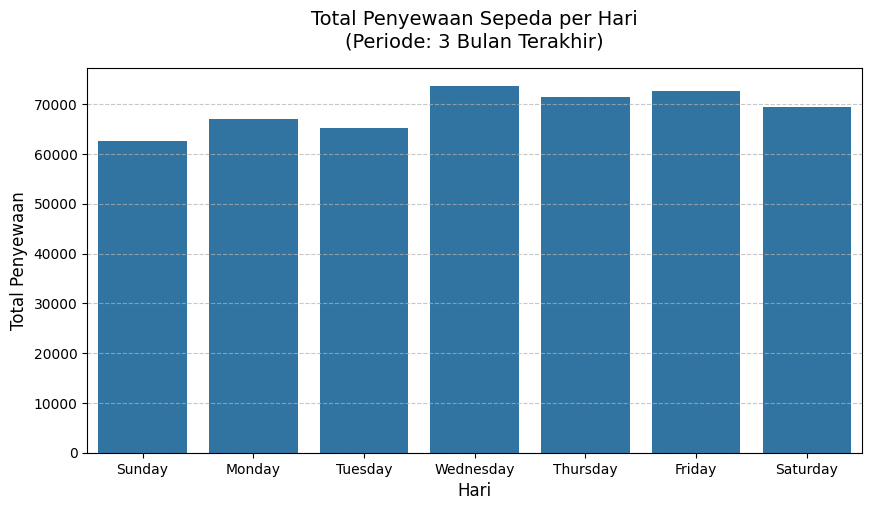

In [58]:
day_plot_data = recent_3_months_df.groupby("weekday_name", observed=False)["cnt"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(x="weekday_name", y="cnt", data=day_plot_data, color="tab:blue")

plt.title("Total Penyewaan Sepeda per Hari\n(Periode: 3 Bulan Terakhir)", fontsize=14, pad=15)
plt.xlabel("Hari", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Pertanyaan 2: Di jam berapa yang paling banyak disewa?

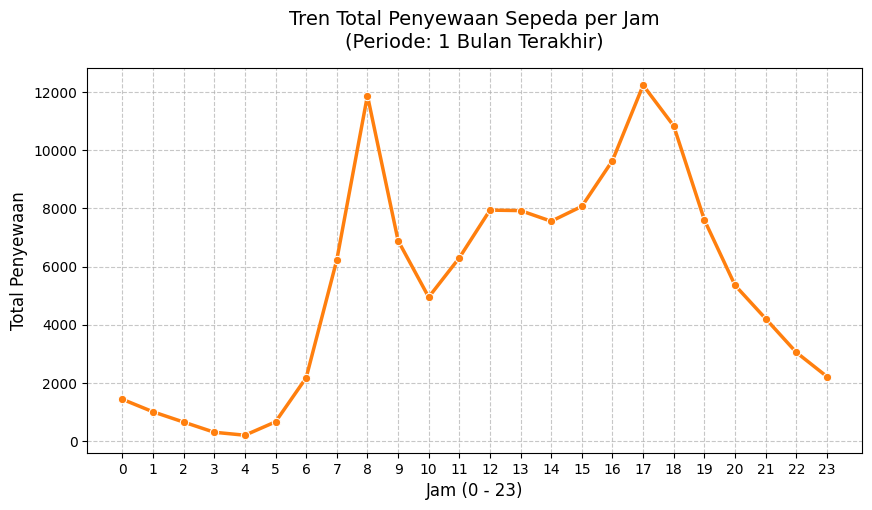

In [59]:
hour_plot_data = recent_1_month_df.groupby("hr")["cnt"].sum().reset_index()

plt.figure(figsize=(10, 5))
sns.lineplot(x="hr", y="cnt", data=hour_plot_data, color="tab:orange", linewidth=2.5, marker="o")

plt.title("Tren Total Penyewaan Sepeda per Jam\n(Periode: 1 Bulan Terakhir)", fontsize=14, pad=15)
plt.xlabel("Jam (0 - 23)", fontsize=12)
plt.ylabel("Total Penyewaan", fontsize=12)
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

**Insight:**
- Melalui bar chart, terlihat jelas bahwa tinggi diagram batang mengalami penurunan signifikan saat memasuki akhir pekan, dengan titik terendah (tiang terpendek) berada di hari Sunday (Minggu).
- Line chart memvisualisasikan tren waktu yang sangat jelas dengan pola bimodal (dua puncak). Puncak pertama terbentuk di angka 8 (pagi hari), dan puncak tertinggi tercipta pada angka 17 hingga 18 (sore hari). Rentang jam tengah malam hingga subuh terlihat sangat landai mendekati nol.

## Analisis Lanjutan (Opsional)

## Conclusion

- Conclution pertanyaan 1 : Mengacu pada kinerja selama 3 bulan terakhir, penyewaan sepeda memuncak pada hari kerja dan menurun drastis di hari Minggu. Sebagai acuan jadwal promosi, hari Minggu adalah waktu yang paling tepat untuk meluncurkan kampanye diskon atau "Paket Akhir Pekan" guna menstimulasi permintaan dan memaksimalkan utilitas sepeda di hari yang sepi tersebut.
- Conclution pertanyaan 2 : Rekaman data operasional 1 bulan terakhir mengonfirmasi bahwa rentang jam penyewaan mengalami lonjakan tertinggi pada pukul 17:00 hingga 18:00 sore, disusul puncak kedua pada pukul 08:00 pagi. Karena ini adalah jam-jam sibuk komuter, manajemen disarankan untuk mengalokasikan staf lebih banyak di lapangan pada rentang waktu tersebut untuk menghindari antrean panjang dan memperlancar proses transaksi pelanggan.